In [16]:
import numpy as np
import yfinance as yf
import pandas as pd
from datetime import date 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import math

In [17]:


#TICKER_A = "GC=F"
#TICKER_B = "SI=F"

TICKER_A = "GLD"
TICKER_B = "SLV"

START = "1979-01-01"
END = date.today().strftime("%Y-%m-%d")

LOOKBACK_WINDOW = 120

data = yf.download([TICKER_A, TICKER_B], start=START, end=END, group_by="column")

#df = data[[TICKER_A]].dropna()

print(data)

[*********************100%***********************]  2 of 2 completed

Price            Close                   High                    Low  \
Ticker             GLD        SLV         GLD        SLV         GLD   
Date                                                                   
2004-11-18   44.380001        NaN   44.490002        NaN   44.070000   
2004-11-19   44.779999        NaN   44.919998        NaN   44.470001   
2004-11-22   44.950001        NaN   44.970001        NaN   44.740002   
2004-11-23   44.750000        NaN   44.919998        NaN   44.720001   
2004-11-24   45.049999        NaN   45.049999        NaN   44.790001   
...                ...        ...         ...        ...         ...   
2026-06-16  397.630005  63.389999  398.959991  63.849998  395.820007   
2026-06-17  388.600006  60.610001  402.040009  64.690002  387.079987   
2026-06-18  387.119995  59.509998  392.500000  61.119999  385.600006   
2026-06-22  384.589996  58.910000  386.410004  60.330002  382.640015   
2026-06-23  377.320007  55.730000  380.350006  56.509998  377.17

In [18]:
print(type(data))
data.head()
data.columns

<class 'pandas.DataFrame'>


MultiIndex([( 'Close', 'GLD'),
            ( 'Close', 'SLV'),
            (  'High', 'GLD'),
            (  'High', 'SLV'),
            (   'Low', 'GLD'),
            (   'Low', 'SLV'),
            (  'Open', 'GLD'),
            (  'Open', 'SLV'),
            ('Volume', 'GLD'),
            ('Volume', 'SLV')],
           names=['Price', 'Ticker'])

In [19]:
close_df = data.loc[:, 'Close']
close_df.head()
close_df.columns

Index(['GLD', 'SLV'], dtype='str', name='Ticker')

In [20]:
# Ratio 


close_df["Ratio"] = close_df[TICKER_A] / close_df[TICKER_B] # GC=F / SI=F

# calculate 30 day rolling statistics 
close_df["Rolling_Mean"] = close_df["Ratio"].rolling(window=LOOKBACK_WINDOW).mean()
close_df["Rolling_Std"] = close_df["Ratio"].rolling(window=LOOKBACK_WINDOW).std()

# Calculate the Rolling Z-Score
close_df["Z_Score"] = (close_df["Ratio"] - close_df["Rolling_Mean"]) / close_df["Rolling_Std"]


close_df.head()

Ticker,GLD,SLV,Ratio,Rolling_Mean,Rolling_Std,Z_Score
Date,,,,,,
2004-11-18,44.380001,NaN,NaN,NaN,NaN,NaN
2004-11-19,44.779999,NaN,NaN,NaN,NaN,NaN
2004-11-22,44.950001,NaN,NaN,NaN,NaN,NaN
2004-11-23,44.750000,NaN,NaN,NaN,NaN,NaN
2004-11-24,45.049999,NaN,NaN,NaN,NaN,NaN


In [21]:
final_df = close_df[[TICKER_A, TICKER_B, "Ratio", "Z_Score"]].dropna()

print("\n--- Latest 10 Trading Days (Gold/Silver Ratio) ---")
print(final_df.tail(10).to_string())


--- Latest 10 Trading Days (Gold/Silver Ratio) ---
Ticker             GLD        SLV     Ratio   Z_Score
Date                                                 
2026-06-09  390.779999  59.009998  6.622268  1.167826
2026-06-10  374.579987  57.660000  6.496358  0.911309
2026-06-11  386.320007  60.820000  6.351858  0.605691
2026-06-12  386.540009  61.290001  6.306739  0.518676
2026-06-15  396.549988  63.470001  6.247833  0.396540
2026-06-16  397.630005  63.389999  6.272756  0.457901
2026-06-17  388.600006  60.610001  6.411483  0.763665
2026-06-18  387.119995  59.509998  6.505125  0.964538
2026-06-22  384.589996  58.910000  6.528433  1.000249
2026-06-23  377.320007  55.730000  6.770501  1.503959


In [22]:
print(f"Total rows in final_df: {len(final_df)}")
print(f"Date range: {final_df.index.min()} to {final_df.index.max()}")

Total rows in final_df: 4950
Date range: 2006-10-17 00:00:00 to 2026-06-23 00:00:00


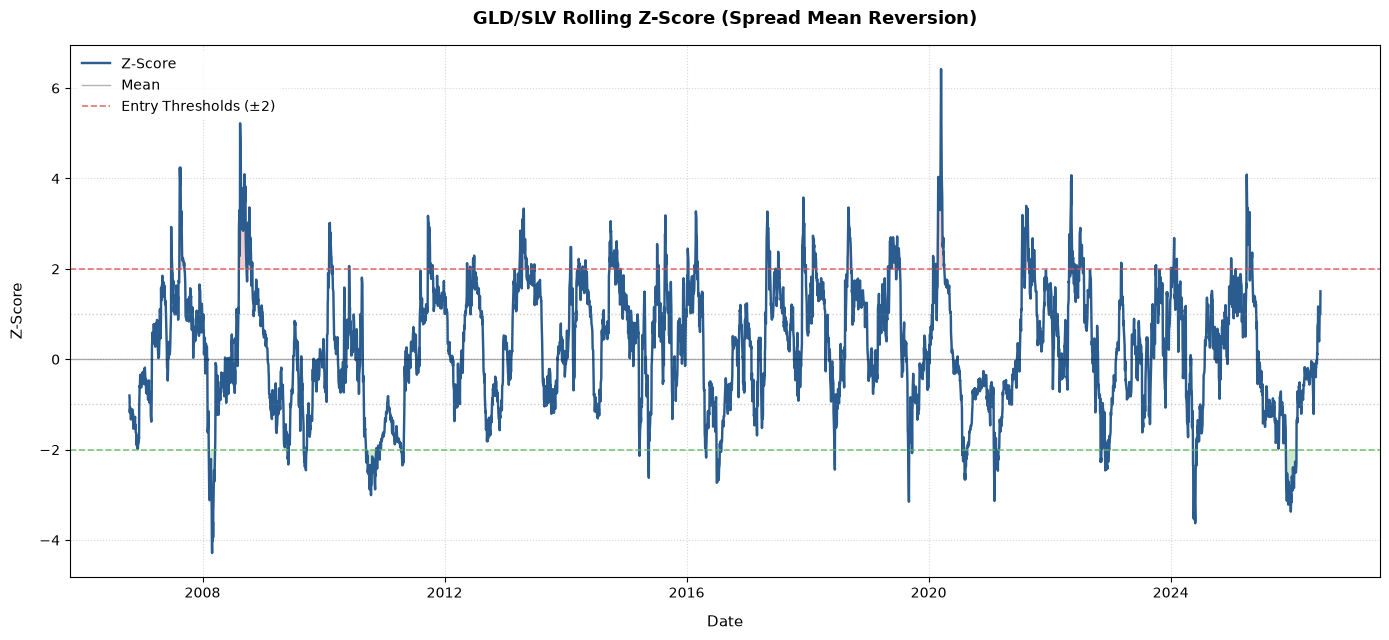

In [23]:
#close_df = final_df.tail(90)
close_df = final_df

plt.figure(figsize=(14, 6.5))  # Slightly wider aspect ratio for a cleaner timeline

# Plot the rolling Z-Score
plt.plot(
    close_df.index,
    close_df["Z_Score"],
    color="#2b5c8f",
    linewidth=1.75,
    label="Z-Score"
)

# Trading thresholds
plt.axhline(0, color="black", linestyle="-", alpha=0.3, linewidth=1, label="Mean")
plt.axhline(2, color="#d9534f", linestyle="--", alpha=0.8, linewidth=1.2, label="Entry Thresholds (±2)")
plt.axhline(-2, color="#5cb85c", linestyle="--", alpha=0.8, linewidth=1.2)
plt.axhline(1, color="gray", linestyle=":", alpha=0.4, linewidth=1)
plt.axhline(-1, color="gray", linestyle=":", alpha=0.4, linewidth=1)

z = close_df["Z_Score"]

# Shade "Short the Spread" territory (Z >= 2)
# Shading from the +2 threshold up to the actual Z-score
plt.fill_between(
    close_df.index,
    2,
    z,
    where=(z >= 2),
    facecolor="#d9534f",
    alpha=0.3,
    interpolate=True
)

# Shade "Long the Spread" territory (Z <= -2)
# Shading from the -2 threshold down to the actual Z-score
plt.fill_between(
    close_df.index,
    -2,
    z,
    where=(z <= -2),
    facecolor="#5cb85c",
    alpha=0.3,
    interpolate=True
)

# Formatting
plt.title(f"{TICKER_A}/{TICKER_B} Rolling Z-Score (Spread Mean Reversion)", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Date", fontsize=11, labelpad=10)
plt.ylabel("Z-Score", fontsize=11, labelpad=10)

# Clean up legend (combining the ±2 lines under a single label)
plt.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none")
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()

plt.show()


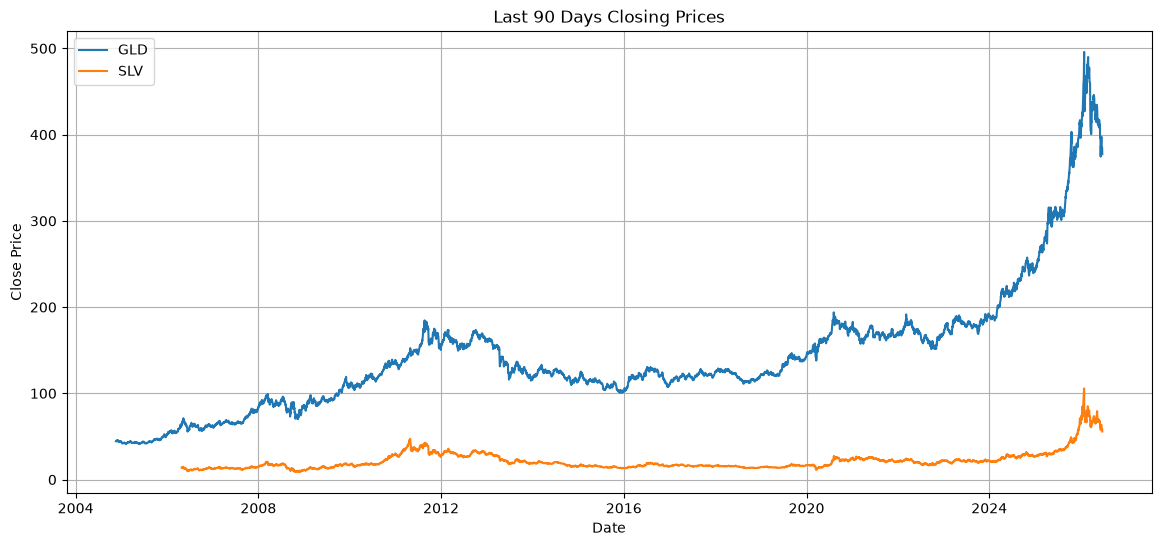

In [24]:
# Extract only Close prices
close = data["Close"]

# Take last 90 days WITHOUT mutating anything
#close_90 = close.tail(90).copy()
close_90 = close

plt.figure(figsize=(14, 6))

plt.plot(close_90.index, close_90[TICKER_A], label=TICKER_A)

plt.plot(close_90.index, close_90[TICKER_B], label=TICKER_B)

plt.title("Last 90 Days Closing Prices")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)

plt.show()


In [25]:


# Z-Score Interpretation (Ratio = Gold / Silver):
# Z_Score > +2: Gold is OVERVALUED relative to Silver → Short Gold / Long Silver
# Z_Score < -2: Gold is UNDERVALUED relative to Silver → Long Gold / Short Silver

high_ratio_rows = final_df[final_df["Z_Score"] > 2]  # Gold overvalued → mean reversion expected downward
high_ratio_rows.tail()


Ticker,GLD,SLV,Ratio,Z_Score
Date,,,,
2025-04-29,306.059998,29.830000,10.260141,2.199373
2025-04-30,303.769989,29.600000,10.262499,2.146271
2025-05-05,306.880005,29.480000,10.409770,2.268099
2025-05-06,315.480011,30.219999,10.439445,2.255302
2025-05-07,310.750000,29.490000,10.537470,2.361159


In [26]:
# --- Backtest Parameters ---
ENTRY_UPPER = 2.0  # Short the ratio / Sell the spread
ENTRY_LOWER = -2.0  # Buy the ratio / Buy the spread
EXIT_LEVEL = 0.0  # Take profit at the mean

# --- Vectorized Signal Generation ---
# 1. Identify raw position states based on barriers
close_df["Signal"] = 0
close_df.loc[close_df["Z_Score"] > ENTRY_UPPER, "Signal"] = -1  # Short Spread
close_df.loc[close_df["Z_Score"] < ENTRY_LOWER, "Signal"] = 1  # Long Spread

# 2. Forward-fill positions to simulate holding the asset until exit
# To properly enforce the exit condition (crossing 0), we find where Z-score crosses zero
# and map out the precise trade windows.
position = 0
positions = []

# Using a single pass array loop for the state machine to handle the conditional holding lockouts cleanly
z_scores = close_df["Z_Score"].values
for z in z_scores:
    if position == 0:
        if z > ENTRY_UPPER:
            position = -1
        elif z < ENTRY_LOWER:
            position = 1
    elif position == -1 and z <= EXIT_LEVEL:
        position = 0
    elif position == 1 and z >= EXIT_LEVEL:
        position = 0
    positions.append(position)

close_df["Position"] = positions

# --- Performance & Trade Statistics Extraction ---
# Find exact entry points (where position changes from 0 to non-zero)
close_df["Trades"] = close_df["Position"].diff().fillna(0)
entries = close_df[
    (close_df["Trades"] != 0) & (close_df["Position"] != 0)
].copy()
exits = close_df[
    (close_df["Trades"] != 0) & (close_df["Position"] == 0)
].copy()

# Ensure we align matching entry and exit pairs
if len(entries) > len(exits):
    entries = entries.iloc[: len(exits)]

# Calculate returns per trade using the raw spread Ratio changes
trade_records = []
for ent, ex in zip(entries.itertuples(), exits.itertuples()):
    # Capture trade orientation
    direction = "Long" if ent.Position == 1 else "Short"

    # Vectorized return based on spread expansion/contraction
    if direction == "Long":
        ret = (ex.Ratio / ent.Ratio) - 1
    else:
        ret = 1 - (ex.Ratio / ent.Ratio)

    trade_records.append(
        {
            "Entry_Date": ent.Index,
            "Exit_Date": ex.Index,
            "Direction": direction,
            "Return": ret,
            "Holding_Period": (ex.Index - ent.Index).days,
        }
    )

trades_df = pd.DataFrame(trade_records)

# --- Compute Win-Rate and Key Metrics ---
win_rate = (trades_df["Return"] > 0).mean() * 100
avg_return = trades_df["Return"].mean() * 100
avg_hold = trades_df["Holding_Period"].mean()

print("========================================")
print("     Z-SCORE STRATEGY BACKTEST RESULTS  ")
print("========================================")
print(f"Total Completed Trades : {len(trades_df)}")
print(f"Strategy Win Rate      : {win_rate:.2f}%")
print(f"Average Return / Trade : {avg_return:.2f}%")
print(f"Average Holding Period : {avg_hold:.1f} Calendar Days")
print("========================================")

# Show a snippet of the exact execution ledger
trades_df.head(10)

     Z-SCORE STRATEGY BACKTEST RESULTS  
Total Completed Trades : 37
Strategy Win Rate      : 54.05%
Average Return / Trade : -0.81%
Average Holding Period : 107.7 Calendar Days


,Entry_Date,Exit_Date,Direction,Return,Holding_Period
0,2007-06-26,2008-01-18,Short,-0.041073,206
1,2008-02-08,2008-05-16,Long,-0.004746,98
2,2008-08-08,2009-01-29,Short,-0.313389,174
3,2009-05-28,2009-07-02,Long,0.098504,35
4,2009-09-03,2009-11-02,Long,0.047451,60
5,2010-02-03,2010-03-29,Short,0.056491,54
6,2010-06-04,2010-07-14,Short,0.057757,40
7,2010-09-14,2011-05-12,Long,-0.288750,240
8,2011-09-23,2012-02-07,Short,0.042774,137
9,2012-05-16,2012-08-23,Short,0.035031,99


       GROWTH OF $100 OVER TIME         
Starting Capital : $100.00
Final Balance    : $60.78
Total Net Return : -39.22%
Peak Account Value: $100.00


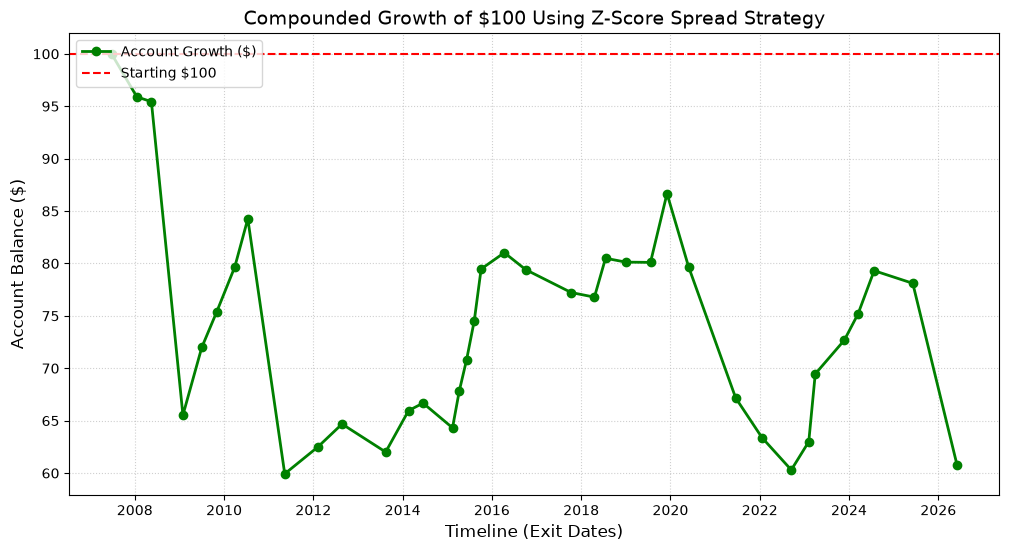

In [27]:
# --- Capital Allocation & Compounding Curve Calculation ---
INITIAL_CAPITAL = 100.0

# Calculate the compounded return multiplier path
# (1 + r_1) * (1 + r_2) * ... * (1 + r_n)
trades_df["Cumulative_Multiplier"] = (1 + trades_df["Return"]).cumprod()
trades_df["Account_Balance"] = INITIAL_CAPITAL * trades_df["Cumulative_Multiplier"]

# Insert a starting row at index -1 to represent Day 0 before any trades occurred
start_row = pd.DataFrame(
    [
        {
            "Entry_Date": trades_df["Entry_Date"].iloc[0] - pd.Timedelta(days=1),
            "Exit_Date": trades_df["Entry_Date"].iloc[0] - pd.Timedelta(days=1),
            "Direction": "None",
            "Return": 0.0,
            "Holding_Period": 0,
            "Cumulative_Multiplier": 1.0,
            "Account_Balance": INITIAL_CAPITAL,
        }
    ]
)

# Combine the starting row with our performance ledger
equity_curve = pd.concat([start_row, trades_df], ignore_index=True)

final_balance = equity_curve["Account_Balance"].iloc[-1]
total_pct_return = ((final_balance - INITIAL_CAPITAL) / INITIAL_CAPITAL) * 100
peak_balance = equity_curve["Account_Balance"].max()

print("========================================")
print("       GROWTH OF $100 OVER TIME         ")
print("========================================")
print(f"Starting Capital : ${INITIAL_CAPITAL:.2f}")
print(f"Final Balance    : ${final_balance:.2f}")
print(f"Total Net Return : {total_pct_return:.2f}%")
print(f"Peak Account Value: ${peak_balance:.2f}")
print("========================================")

# --- Plotting the Equity Curve ---
plt.figure(figsize=(12, 6))
plt.plot(
    equity_curve["Exit_Date"],
    equity_curve["Account_Balance"],
    marker="o",
    linestyle="-",
    color="green",
    linewidth=2,
    label="Account Growth ($)",
)
plt.axhline(INITIAL_CAPITAL, color="red", linestyle="--", label="Starting $100")
plt.title("Compounded Growth of $100 Using Z-Score Spread Strategy", fontsize=14)
plt.xlabel("Timeline (Exit Dates)", fontsize=12)
plt.ylabel("Account Balance ($)", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper left")
plt.show()

In [28]:
# --- Single-Direction Long Only Parameters ---
ENTRY_LOWER = -2.0  # Buy the ratio (Gold is cheap)
EXIT_LEVEL = 0.0  # Take profit at the historical mean
INITIAL_CAPITAL = 100.0

# --- Long-Only State Machine ---
position = 0
positions = []
z_scores = close_df["Z_Score"].values

for z in z_scores:
    if position == 0:
        if z < ENTRY_LOWER:
            position = 1  # Gold is cheap! Buy the spread.
    elif position == 1 and z >= EXIT_LEVEL:
        position = 0  # Reverted back to average! Sell, lock in profit.

    positions.append(position)

close_df["Position"] = positions

# --- Extract Trades & Compound Capital ---
close_df["Trades"] = close_df["Position"].diff().fillna(0)
entries = close_df[(close_df["Trades"] == 1) & (close_df["Position"] == 1)].copy()
exits = close_df[(close_df["Trades"] == -1) & (close_df["Position"] == 0)].copy()

# Match entry/exit pairs cleanly
if len(entries) > len(exits):
    entries = entries.iloc[: len(exits)]

trade_records = []
for ent, ex in zip(entries.itertuples(), exits.itertuples()):
    # Percentage return of the ratio rising back to the mean
    ret = (ex.Ratio / ent.Ratio) - 1

    trade_records.append(
        {
            "Entry_Date": ent.Index,
            "Exit_Date": ex.Index,
            "Return": ret,
            "Holding_Period": (ex.Index - ent.Index).days,
        }
    )

long_trades_df = pd.DataFrame(trade_records)

# Calculate the compounded capital path (Keeping profit + principal for the next trade)
long_trades_df["Cumulative_Multiplier"] = (1 + long_trades_df["Return"]).cumprod()
long_trades_df["Account_Balance"] = (
    INITIAL_CAPITAL * long_trades_df["Cumulative_Multiplier"]
)

# --- Print the Results ---
win_rate = (long_trades_df["Return"] > 0).mean() * 100
final_balance = long_trades_df["Account_Balance"].iloc[-1]

print("========================================")
print("   LONG-ONLY Z-SCORE STRATEGY RESULTS   ")
print("========================================")
print(f"Total Completed Trades : {len(long_trades_df)}")
print(f"Strategy Win Rate      : {win_rate:.2f}%")
print(f"Starting Capital       : ${INITIAL_CAPITAL:.2f}")
print(f"Final Compounded Value : ${final_balance:.2f}")
print("========================================")

long_trades_df.tail()

   LONG-ONLY Z-SCORE STRATEGY RESULTS   
Total Completed Trades : 13
Strategy Win Rate      : 61.54%
Starting Capital       : $100.00
Final Compounded Value : $72.08


,Entry_Date,Exit_Date,Return,Holding_Period,Cumulative_Multiplier,Account_Balance
8,2019-09-03,2019-12-04,0.081958,92,0.996712,99.671183
9,2020-07-22,2021-06-18,-0.156876,331,0.840352,84.035159
10,2022-11-04,2023-02-06,0.044708,94,0.877922,87.792223
11,2024-05-15,2024-07-25,0.054927,71,0.926144,92.614385
12,2025-11-26,2026-06-03,-0.221769,189,0.720754,72.075420
